In [1]:
# === Core Python Utilities ===
import os
import re
import math
import random
import warnings
from datetime import datetime
from itertools import combinations
from collections import Counter
from typing import List, Tuple, Dict, Optional

# === Scientific Computing ===
import numpy as np
import pandas as pd
import scipy
from scipy.stats import skew

# === Visualization ===
import matplotlib.pyplot as plt
import seaborn as sns
import missingno
import mplcursors
from matplotlib.colors import LinearSegmentedColormap

# === Progress & Optimization ===
from tqdm.notebook import tqdm
tqdm.pandas()
import optuna

# === Data Preprocessing ===
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, PowerTransformer,
    OneHotEncoder, LabelEncoder, OrdinalEncoder
)
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectFromModel
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.manifold import TSNE


# === Train/Test Splits & Cross-Validation ===
from sklearn.model_selection import (
    train_test_split, KFold, StratifiedKFold,
    cross_val_predict, cross_val_score,
    GridSearchCV, RandomizedSearchCV, ParameterGrid
)

# === Metrics & Evaluation ===
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, auc, roc_curve,
    classification_report, confusion_matrix,
    precision_recall_curve, make_scorer
)

from sklearn.decomposition import PCA
# === Pipelines ===
from sklearn.pipeline import make_pipeline

# === Machine Learning Models ===
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

from xgboost import XGBClassifier
import xgboost as xgb

from lightgbm import LGBMClassifier
import lightgbm as lgb
from catboost import CatBoostClassifier

# from catboost import CatBoostClassifier, CatBoostRegressor, Pool, cv
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import optuna

In [2]:
from training_module import (
    evaluate_model,                     # Hàm thực hiện đánh giá mô hình trên tập dev và test
    optimize_threshold_by_f1           # Hàm thực hiện tối ưu hoá ngưỡng phân loại
)

In [4]:
# Một số setting cơ bản
import warnings
import pandas as pd
warnings.filterwarnings ('ignore')
pd.set_option ('display.width', None)
pd.set_option ('display.max_rows', 100)
pd.set_option ('display.max_columns', 50)

In [3]:
file_path = '/Users/kittnguyen/Documents/us-flight-project/data/silver_data/'
X_train = np.load(f"{file_path}train/X_train.npy", allow_pickle=True)
y_train = np.load(f"{file_path}train/y_train.npy", allow_pickle=True)
X_dev = np.load(f"{file_path}dev/X_dev.npy", allow_pickle=True)
y_dev = np.load(f"{file_path}dev/y_dev.npy", allow_pickle=True)
X_test = np.load(f"{file_path}test/X_test.npy", allow_pickle=True)
y_test = np.load(f"{file_path}test/y_test.npy", allow_pickle=True)

# AdaBoost

## Training

In [5]:
from sklearn.ensemble import AdaBoostClassifier

# --- AdaBoost Classifier ---
ada_model = AdaBoostClassifier(
    n_estimators=300,
    learning_rate=0.05,
    random_state=42
)

# --- Training ---
ada_model.fit(X_train, y_train)

,estimator,None
,n_estimators,300
,learning_rate,0.05
,algorithm,'deprecated'
,random_state,42


## Predicting & Evaluating

### Dev

Evaluation on  set:
Accuracy : 0.6452
Precision: 0.6795
Recall   : 0.1207
F1-score : 0.205
ROC AUC  : 0.6591


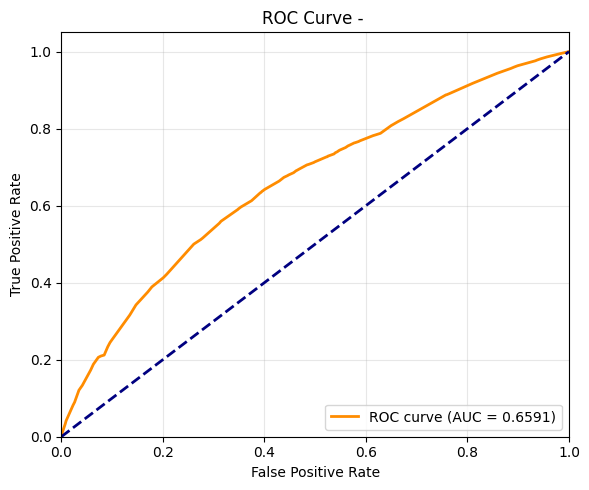

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.97      0.77    837529
           1       0.68      0.12      0.21    511152

    accuracy                           0.65   1348681
   macro avg       0.66      0.54      0.49   1348681
weighted avg       0.66      0.65      0.56   1348681



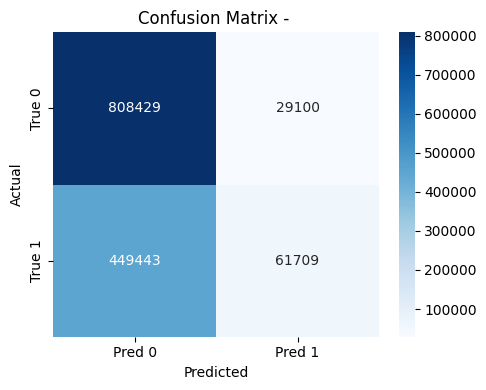

Best threshold: 0.50 with F1-score: 1.0000


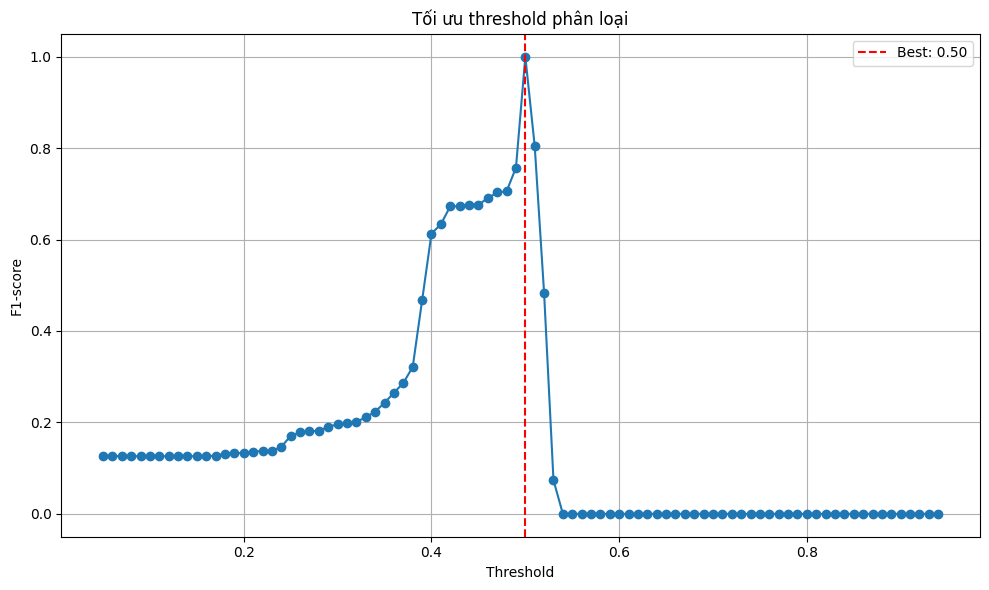

(np.float64(0.5000000000000001), 1.0)

In [6]:
# --- Predicting ---
y_pred_dev = ada_model.predict(X_dev)
y_proba_dev = ada_model.predict_proba(X_dev)[:, 1] # Probability

# --- Evaluating ---
evaluate_model (y_dev, y_pred_dev, y_proba_dev)

# --- Optimizing ---
optimize_threshold_by_f1 (ada_model, X_dev, y_pred_dev)

### Test

Evaluation on  set:
Accuracy : 0.6454
Precision: 0.6804
Recall   : 0.1212
F1-score : 0.2057
ROC AUC  : 0.6594


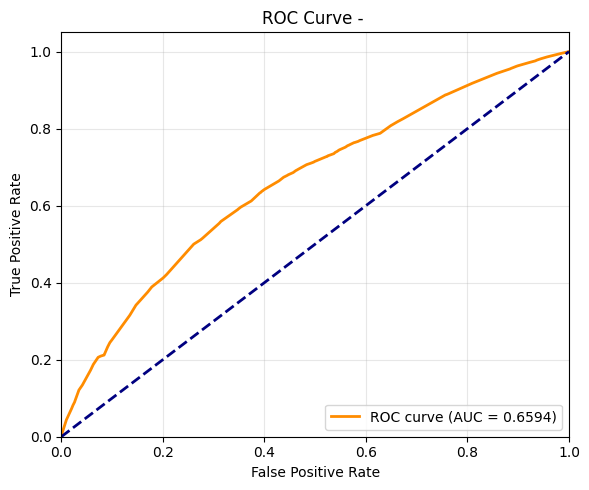

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.97      0.77    837529
           1       0.68      0.12      0.21    511152

    accuracy                           0.65   1348681
   macro avg       0.66      0.54      0.49   1348681
weighted avg       0.66      0.65      0.56   1348681



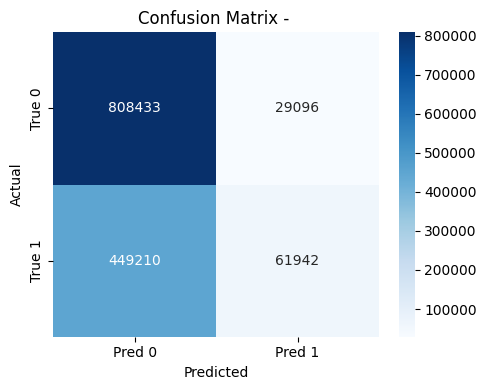

Best threshold: 0.50 with F1-score: 1.0000


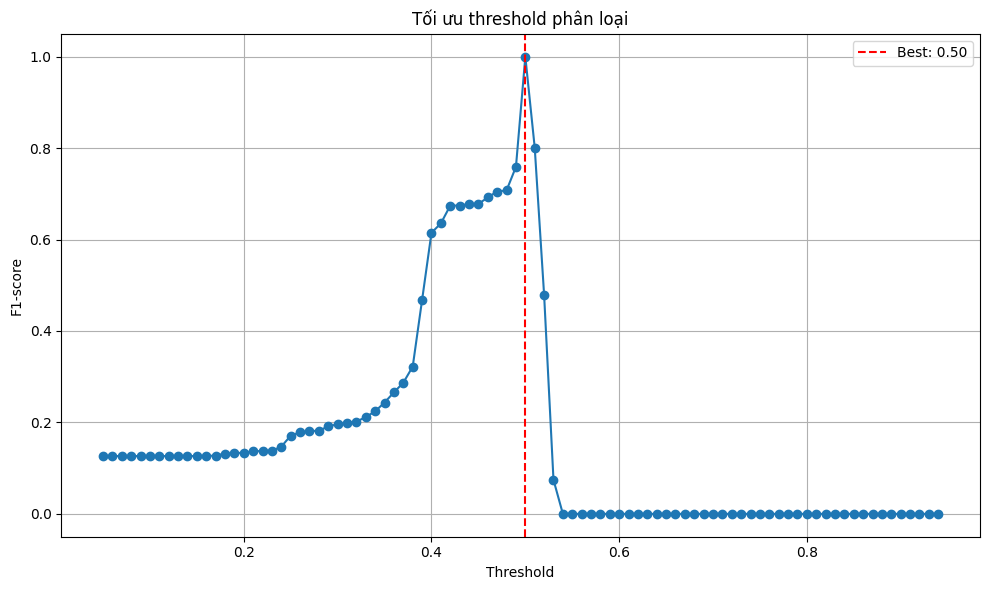

(np.float64(0.5000000000000001), 1.0)

In [7]:
# --- Predicting ---
y_pred_test = ada_model.predict(X_test)
y_proba_test = ada_model.predict_proba(X_test)[:, 1] # Probability

# --- Evaluating ---
evaluate_model (y_test, y_pred_test, y_proba_test)

# --- Optimizing ---
optimize_threshold_by_f1 (ada_model, X_test, y_pred_test)